<a href="https://colab.research.google.com/github/Saurabh312Kumar/ML-Concepts/blob/main/Logistic_Regression_titanic_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import  StratifiedKFold, cross_val_score,train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

In [ ]:
train=pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [ ]:
print(train.shape)

(891, 12)


In [ ]:
print(test.shape)

(418, 11)


In [ ]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
train.columns = train.columns.str.lower()
test.columns = test.columns.str.lower()

In [ ]:
print(train.columns)
print(test.columns)

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')
Index(['passengerid', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch',
       'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')


<Axes: >

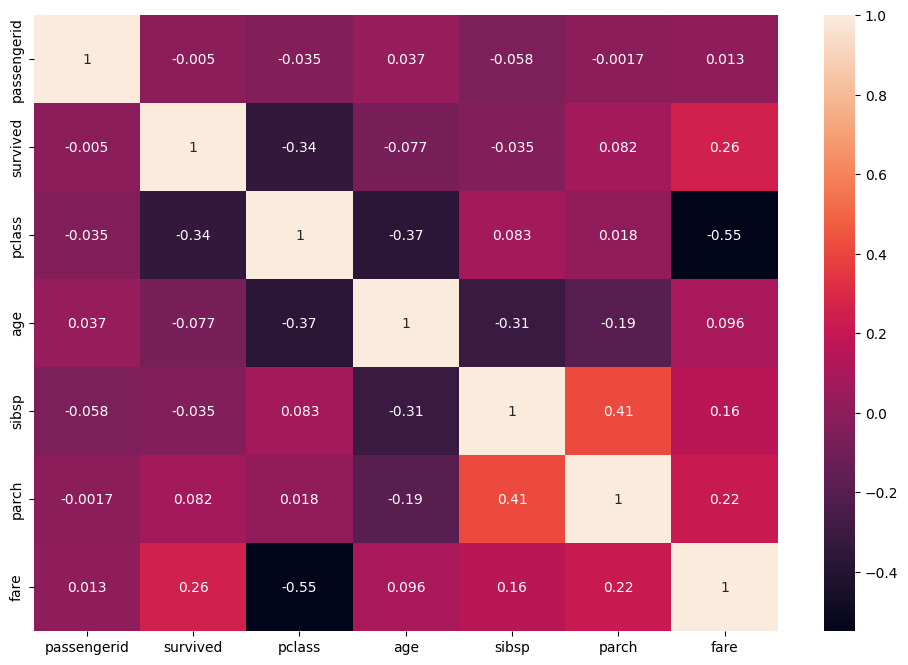

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(train.corr(numeric_only=True),annot=True)

<Axes: xlabel='sex', ylabel='count'>

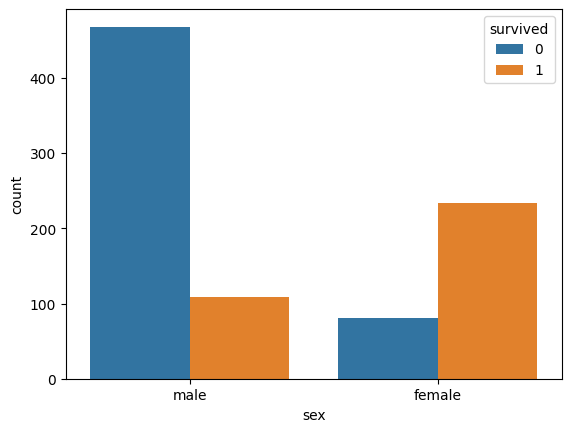

In [ ]:
sns.countplot(
    data=train,
    x='sex',
    hue='survived'
)

<Axes: xlabel='age'>

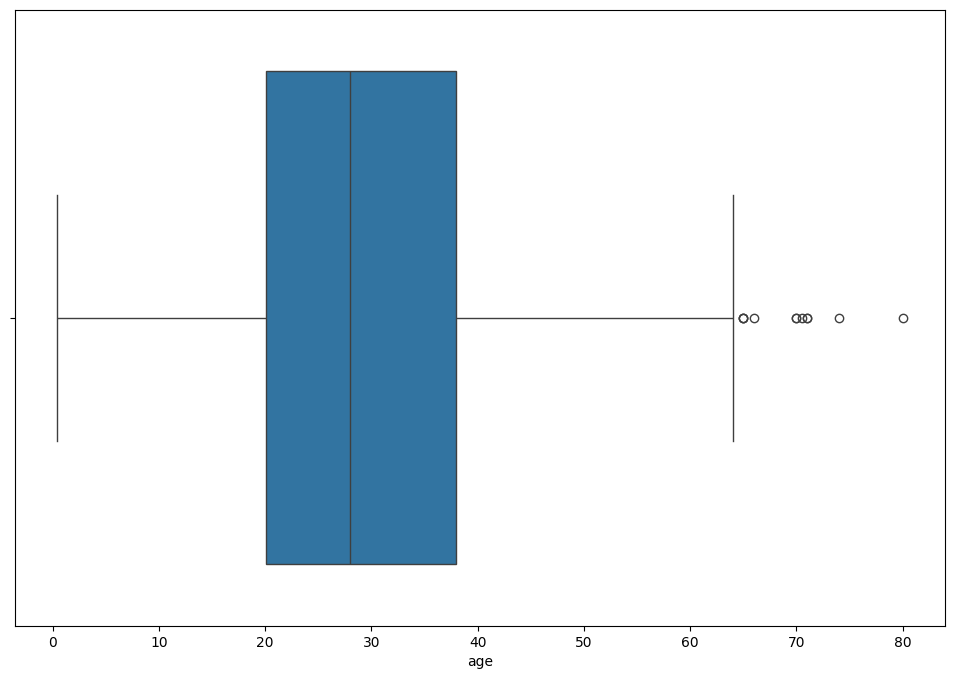

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(train,x='age')

<Axes: xlabel='age', ylabel='Count'>

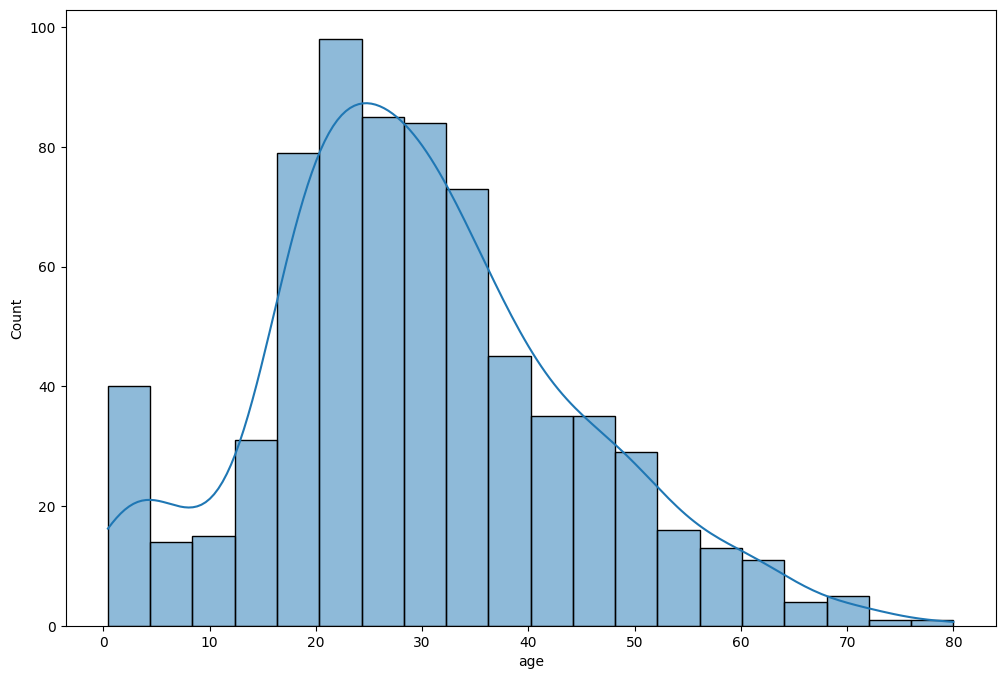

In [ ]:
plt.figure(figsize=(12,8))
sns.histplot(train,x='age',kde=True)

In [ ]:
X_train,X_val,y_train,y_val=train_test_split(train.drop(columns=['survived','name','ticket']),train['survived'],stratify=train['survived'],test_size=0.2,random_state=42)

In [ ]:
median_age=X_train['age'].median()
X_train['age']=X_train['age'].fillna(median_age)
X_val['age']=X_val['age'].fillna(median_age)


In [ ]:
print(X_val.columns.tolist())

['passengerid', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'cabin', 'embarked']


In [ ]:
print(X_train.columns.tolist())

['passengerid', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'cabin', 'embarked']


In [ ]:
embark_mode=X_train['embarked'].mode()[0]
X_train['embarked']=X_train['embarked'].fillna(embark_mode)
X_val['embarked']=X_val['embarked'].fillna(embark_mode)

In [ ]:
X_train=X_train.drop(columns=['cabin'])
X_val=X_val.drop(columns=['cabin'])

In [ ]:
X_train=pd.get_dummies(X_train,columns=['sex','embarked'],drop_first=True)
X_val=pd.get_dummies(X_val,columns=['sex','embarked'],drop_first=True)

In [ ]:
X_val = X_val.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [ ]:
X_train=X_train.astype(float)
X_val=X_val.astype(float)

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(solver='liblinear'))
])

In [ ]:
num_folds=5
sfold=StratifiedKFold(n_splits=num_folds,shuffle=True,random_state=42)

In [ ]:
cross_val_result=cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=sfold
)

In [ ]:
param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2']
}

In [ ]:
lr_cv=GridSearchCV(pipeline,param_grid,cv=sfold,scoring='accuracy')
lr_cv.fit(X_train,y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        LogisticRegression(solver='liblinear'))]),
             param_grid={'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'model__penalty': ['l1', 'l2']},
             scoring='accuracy')

In [ ]:
print(lr_cv.best_params_)

{'model__C': 0.1, 'model__penalty': 'l2'}


In [ ]:
print(lr_cv.best_score_)

0.7921402541120852


In [ ]:
best_lr_model=lr_cv.best_estimator_
y_pred_best=best_lr_model.predict(X_val)

In [ ]:
print(accuracy_score(y_val,y_pred_best))
print(confusion_matrix(y_val,y_pred_best))
print(classification_report(y_val,y_pred_best))

0.7877094972067039
[[95 15]
 [23 46]]
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       110
           1       0.75      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.78       179



In [ ]:
X_test = test.copy()

In [ ]:
X_test = X_test.drop(columns=['name', 'ticket'])

In [ ]:
X_test['age']=X_test['age'].fillna(median_age)

In [ ]:
X_test['fare']=X_test['fare'].fillna(X_test['fare'].median())

In [ ]:
X_test['embarked']=X_test['embarked'].fillna(embark_mode)

In [ ]:
X_test = X_test.drop(columns=['cabin'])

In [ ]:
X_test = pd.get_dummies(
    X_test,
    columns=['sex', 'embarked'],
    drop_first=True
)

In [ ]:
# Make sure test columns are exactly the same as training columns
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0)

In [ ]:
X_test = X_test.astype(float)

In [ ]:
test_predictions = best_lr_model.predict(X_test)

In [ ]:
#Display predictions
print("Test predictions:")
print(test_predictions)

# Number of predictions
print("Number of predictions:", len(test_predictions))

Test predictions:
[0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 0 1 0 0 0 0 0 0 1 1 0 1
 1 0 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 1 1 1 0 1 1
 1 1 0 1 0 1 0 0 0 0 0 0 1 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0
 1 1 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 1 0 0 1 1 0 1 1 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1
 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 1 1 0 1 0 0 0 0 1 0 0 1 0 1 0 1 0
 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 1
 0 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 1 0 0 1 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 0
 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 1 1 0
 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0
 0 1 1 1 1 1 0 1 0 0 0]
Number of predictions: 418


In [ ]:
submission = pd.DataFrame({
    'passengerid': test['passengerid'],
    'survived': test_predictions
})

print(submission.head())

   passengerid  survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


In [ ]:
submission.to_csv(
    "titanic_predictions.csv",
    index=False
)

print("Predictions saved successfully!")

Predictions saved successfully!
